# Python Notebook that is used to train and export the model for the ESP32

Install dependencies, ideally in a dedicated environment (.venv)

In [ ]:
%pip install -r requirements.txt

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow import lite as tfl

from keras import Model, Input
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Dropout, AveragePooling1D, Flatten, LSTM

from matplotlib import pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
RANDOM_SEED = 42

In [3]:
# load data
df = pd.read_csv('../data/aggregated.csv')

In [4]:
# prepare data
X_flat = df.iloc[:, 1:].values
X = X_flat.reshape(-1, 100, 6)

y = df.iloc[:, 0].values
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [5]:
# change these to what you need for the input shape

samples_per_classification = 100 # so a second of data
signal_count = 6 # the six axes of the IMU

In [6]:
# inputs and outputs of the model
input_shape = (samples_per_classification, signal_count)
num_classes = 7

In [7]:
# this is the LSTM version, may not fit on the board
def lstm_model(input_shape=input_shape, num_classes=num_classes, cells_first=64, cells_second=32) -> Model:
    lstm = Sequential()
    lstm.add(Input(shape=input_shape))
    lstm.add(LSTM(cells_first, return_sequences=True, unroll=True))
    lstm.add(Dropout(0.2))
    lstm.add(LSTM(cells_second, unroll=True))
    lstm.add(Dropout(0.2))
    lstm.add(Dense(cells_second, activation="relu"))
    lstm.add(Dense(num_classes, activation="softmax"))
    
    return lstm

In [ ]:
# This is the CNN model
def cnn_model(input_shape=input_shape, num_classes=num_classes, filters=8, kernel_size=9) -> Model:
    cnn = Sequential()
    cnn.add(Input(shape=input_shape))
    cnn.add(Conv1D(filters=filters, kernel_size=kernel_size))
    cnn.add(Dropout(rate=0.2))
    cnn.add(AveragePooling1D(pool_size=5))
    cnn.add(Flatten())
    cnn.add(Dense(100, activation="relu"))
    cnn.add(Dropout(0.1))
    cnn.add(Dense(num_classes, activation="softmax"))

    return cnn

In [8]:
model = lstm_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,879 (124.53 KB)

 Trainable params: 31,879 (124.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 230ms/step - accuracy: 0.3251 - loss: 1.7700 - val_accuracy: 0.3958 - val_loss: 1.5838
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.4851 - loss: 1.3588 - val_accuracy: 0.4851 - val_loss: 1.2322
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5900 - loss: 1.0496 - val_accuracy: 0.5625 - val_loss: 1.1155
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6488 - loss: 0.9443 - val_accuracy: 0.5982 - val_loss: 0.9493
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6815 - loss: 0.8057 - val_accuracy: 0.6429 - val_loss: 0.8861
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7143 - loss: 0.7517 - val_accuracy: 0.6518 - val_loss: 0.8351
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7567 - loss: 0.6622 - val_accuracy: 0.7113 - val_loss: 0.7771
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7664 - loss: 0.6445 - val_accuracy: 0.6458 -

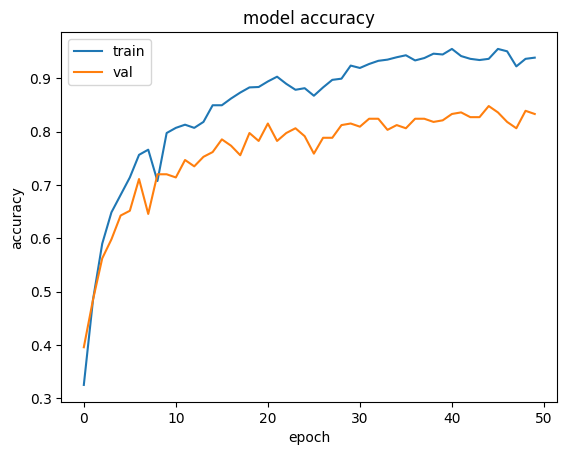

In [9]:
# train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 385ms/step
Accuracy of model: 83.80952380952381%
F1 score per class: [0.85714286 0.78740157 0.82644628 0.85       0.62365591 0.95035461
 0.91428571]


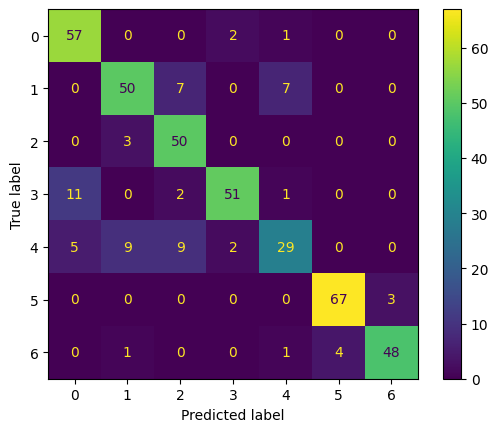

In [10]:
# test the model
predictions = model.predict(X_test)  # Shape: (samples, num_classes)
y_pred = tf.argmax(predictions, axis=1)

accuracy = 100 * accuracy_score(y_test, y_pred)
print(f"Accuracy of model: {accuracy}%")

f1 = f1_score(y_test, y_pred, average=None)
print(f"F1 score per class: {f1}")

# f1 = 100 * f1_score(y_test, y_pred, average="binary")
# print(f"Average f1 score of model: {f1}")

confusion = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion)
disp.plot()
plt.show()

In [13]:
# save the model

# change the file name if needed
model_location = 'model.h5'
model.save(model_location)

# change the converted file name if needed
converted_location = 'model.tflite'

# change the C header file name if needed
# this is what is deployed to the ESP32
header_location = "model.h"

Convert the model to tflite file

In [11]:
def representative_dataset_gen():
    num_samples = 100  # Adjust based on your dataset size (100-500 recommended)
    indices = np.random.choice(len(X_test), num_samples, replace=False)
    for i in indices:
        # Yield as list of float32 tensor (shape must match model input)
        yield [X_test[i:i+1].astype(np.float32)]  # Batch dim of 1

In [14]:
# run this cell if you want to also quantize the model
# otherwise just run the command below

converter = tfl.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tfl.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

tflite_quant_model = converter.convert()
with open(converted_location, 'wb') as f:
    f.write(tflite_quant_model)

INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpepggint3\assets


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpepggint3\assets


Saved artifact at 'C:\Users\Admin\AppData\Local\Temp\tmpepggint3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  1670763248912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670763249488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670769411088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670769412048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670769412432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670769410512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670769413200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670769413776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670769414352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1670769415312: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\Admin\Desktop\EMSYS\Year 1\Q3\Pervasive Computing\Pervasive_Computing_IMU_wearable_device\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
# !tflite_convert --keras_model_file {model_location} --output_file {converted location}

Convert tflite file to C header; make sure xxd is available in the system PATH

In [15]:
!xxd -i {converted_location} > {header_location}